In [ ]:
import pandas as pd

In [7]:
fighter_data = pd.read_csv("ufc_fighters_final.csv")

In [15]:
fighter_data = fighter_data.dropna(subset=['Height', 'Reach'])

In [23]:
fighter_data.isnull().sum() 

Fighter_Name     0
Height           0
Weight           0
Reach            0
Stance          27
DOB              2
Wins             0
Losses           0
Draws            0
SLpM             0
Str_Acc          0
SApM             0
Str_Def          0
TD_Avg           0
TD_Acc           0
TD_Def           0
Sub_Avg          0
Fighter_URL      0
dtype: int64

## changing height, weight, reach to int and floats instead of objects

In [48]:
# changing height, weight, reach to int and floats instead of objects

def parse_height(h):
    try:
        h = h.strip()
        feet, inches = h.replace('"', '').split("'")
        return int(feet) * 12 + int(inches)
    except:
        return None

def parse_reach(r):
    try:
        return float(r.replace('"', '').strip())
    except:
        return None

def parse_weight(w):
    try:
        return float(w.replace('lbs.', '').strip())
    except:
        return None


In [54]:
fighter_data = fighter_data.copy() # incase of errors

In [56]:
fighter_data["Height_in"] = fighter_data["Height"].apply(parse_height)
fighter_data["Reach_in"] = fighter_data["Reach"].apply(parse_reach)
fighter_data["Weight_lbs"] = fighter_data["Weight"].apply(parse_weight)

In [58]:
print(fighter_data[["Height_in", "Reach_in", "Weight_lbs"]].describe())

         Height_in     Reach_in   Weight_lbs
count  2514.000000  2514.000000  2514.000000
mean     69.878679    71.554495   162.277645
std       3.602073     4.267751    34.793028
min      55.000000    58.000000   115.000000
25%      67.000000    69.000000   135.000000
50%      70.000000    72.000000   155.000000
75%      73.000000    75.000000   185.000000
max      83.000000    84.000000   265.000000


In [62]:
fighter_data = fighter_data.drop(columns = ['Height', 'Weight', 'Reach', 'Fighter_URL'])

Fighter_Name     object
Stance           object
DOB              object
Wins              int64
Losses            int64
Draws             int64
SLpM            float64
Str_Acc          object
SApM            float64
Str_Def          object
TD_Avg          float64
TD_Acc           object
TD_Def           object
Sub_Avg         float64
Height_in         int64
Reach_in        float64
Weight_lbs      float64
dtype: object

In [68]:
# ["Str_Acc", "Str_Def", "TD_Acc", "TD_Def"] was in a 00% form
# changin it to decimal form between 0.00 and 1.00

pct_cols = ["Str_Acc", "Str_Def", "TD_Acc", "TD_Def"]

for col in pct_cols:
    fighter_data[col] = fighter_data[col].apply(lambda x: float(x.replace('%', '').strip()) / 100)

print(fighter_data[["Str_Acc", "Str_Def", "TD_Acc", "TD_Def"]].describe())

           Str_Acc      Str_Def       TD_Acc       TD_Def
count  2514.000000  2514.000000  2514.000000  2514.000000
mean      0.444021     0.516317     0.328469     0.539718
std       0.111067     0.113024     0.245079     0.286965
min       0.000000     0.000000     0.000000     0.000000
25%       0.390000     0.460000     0.150000     0.370000
50%       0.450000     0.530000     0.330000     0.590000
75%       0.500000     0.580000     0.480000     0.740000
max       1.000000     1.000000     1.000000     1.000000


In [72]:
fighter_data.dtypes

Fighter_Name     object
Stance           object
DOB              object
Wins              int64
Losses            int64
Draws             int64
SLpM            float64
Str_Acc         float64
SApM            float64
Str_Def         float64
TD_Avg          float64
TD_Acc          float64
TD_Def          float64
Sub_Avg         float64
Height_in         int64
Reach_in        float64
Weight_lbs      float64
dtype: object

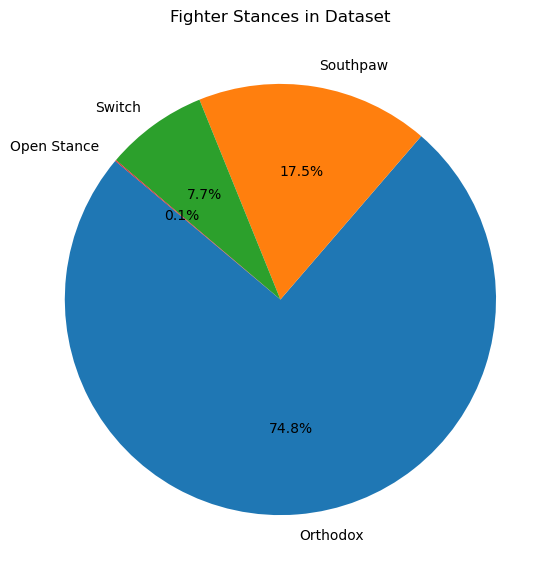

In [27]:
import matplotlib.pyplot as plt

stance_counts = fighter_data["Stance"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(stance_counts, labels=stance_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Fighter Stances in Dataset")
plt.show()

## creating ape index column

In [74]:
# creating ape index column

fighter_data["Ape_Index"] = fighter_data["Reach_in"] - fighter_data["Height_in"]
print(fighter_data["Ape_Index"].describe())

count    2514.000000
mean        1.675815
std         1.969807
min        -7.000000
25%         0.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: Ape_Index, dtype: float64


## putting fighter into ufc official weightclass buckets

In [76]:
# putting fighter into ufc official weightclass buckets

def get_weight_class(w):
    if w <= 125: return "Flyweight"
    elif w <= 135: return "Bantamweight"
    elif w <= 145: return "Featherweight"
    elif w <= 155: return "Lightweight"
    elif w <= 170: return "Welterweight"
    elif w <= 185: return "Middleweight"
    elif w <= 205: return "Light Heavyweight"
    else: return "Heavyweight"


In [78]:
fighter_data["Weight_Class"] = fighter_data["Weight_lbs"].apply(get_weight_class)
print(fighter_data["Weight_Class"].value_counts())

Weight_Class
Lightweight          393
Flyweight            389
Welterweight         369
Bantamweight         366
Featherweight        327
Middleweight         289
Light Heavyweight    198
Heavyweight          183
Name: count, dtype: int64


## ape indexes by weightclass division

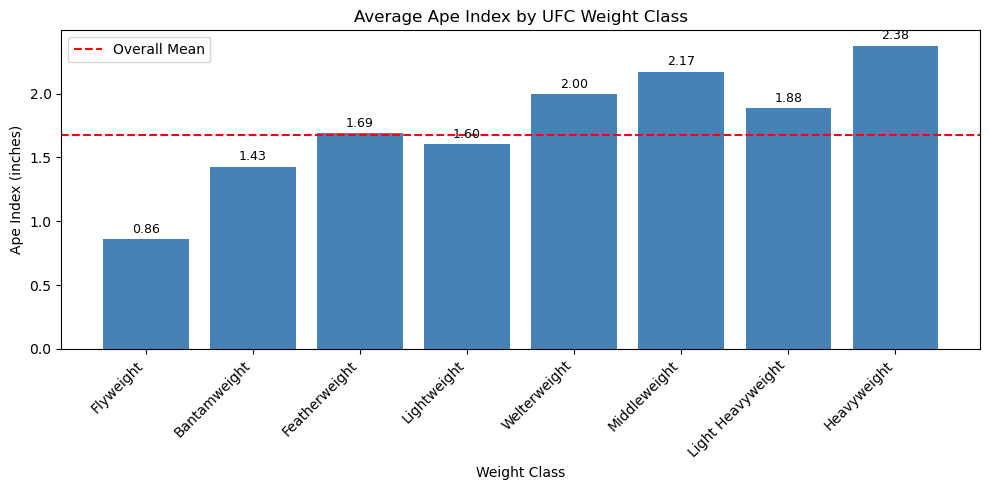

In [84]:
# ape indexes by weightclass division

division_order = [
    "Flyweight", "Bantamweight", "Featherweight", "Lightweight",
    "Welterweight", "Middleweight", "Light Heavyweight", "Heavyweight"
]

ape_by_division = fighter_data.groupby("Weight_Class")["Ape_Index"].mean().reindex(division_order)

plt.figure(figsize=(10, 5))
plt.bar(ape_by_division.index, ape_by_division.values, color="steelblue")
for i, val in enumerate(ape_by_division.values):
    plt.text(i, val + 0.05, f"{val:.2f}", ha="center", fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.title("Average Ape Index by UFC Weight Class")
plt.xlabel("Weight Class")
plt.ylabel("Ape Index (inches)")
plt.axhline(y=fighter_data["Ape_Index"].mean(), color="red", linestyle="--", label="Overall Mean")
plt.legend()
plt.tight_layout()
plt.show()

## mean stats by weightclass

In [88]:
# mean stats by weightclass

fighter_data.groupby("Weight_Class")[["Height_in", "Reach_in",
                                      "SLpM", "Str_Acc", "SApM", "Str_Def", 
                             "TD_Avg", "TD_Acc", "TD_Def", "Sub_Avg", 
                             "Ape_Index"]].mean().reindex(division_order).round(2)

,Height_in,Reach_in,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Ape_Index
Weight_Class,,,,,,,,,,,
Flyweight,65.04,65.90,3.44,0.42,3.92,0.53,1.46,0.33,0.53,0.48,0.86
Bantamweight,67.28,68.71,3.40,0.43,3.85,0.53,1.55,0.32,0.55,0.49,1.43
Featherweight,68.70,70.39,3.54,0.44,3.84,0.52,1.69,0.32,0.53,0.57,1.69
Lightweight,69.96,71.57,3.41,0.44,3.81,0.53,1.49,0.32,0.54,0.62,1.60
Welterweight,71.51,73.51,3.37,0.45,3.75,0.52,1.52,0.36,0.56,0.60,2.00
Middleweight,72.96,75.13,3.27,0.45,3.78,0.50,1.64,0.36,0.52,0.58,2.17
Light Heavyweight,73.89,75.78,3.39,0.48,3.98,0.48,1.42,0.29,0.57,0.50,1.88
Heavyweight,74.77,77.14,3.48,0.48,4.06,0.47,1.40,0.31,0.51,0.48,2.38


In [90]:
fighter_data.to_csv("fighters_cleaned.csv", index=False)
print("cleaned data saved...")

cleaned data saved...
